In [3]:
import os
import random
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn import metrics

import tensorflow as tf
from tensorflow import keras
from keras import layers

import warnings
warnings.filterwarnings('ignore')

In [40]:
import os
import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader

from torchvision import datasets, transforms
from torchvision.models import googlenet, GoogLeNet_Weights

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
!pip install split-folders


In [41]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [11]:
import os
import shutil
import random

# =========================================================
# 1. CHANGE THIS PATH
# =========================================================

SOURCE_DIR = r"/content/drive/MyDrive/Deep Learning/Lung Cancer Project/Lung_images/original_images"

# New dataset will be created here
OUTPUT_DIR = r"/content/drive/MyDrive/Deep Learning/split_dataset"


# =========================================================
# 2. SETTINGS
# =========================================================

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

random.seed(42)

IMAGE_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff"
)


# =========================================================
# 3. CREATE TRAIN / VAL / TEST FOLDERS
# =========================================================

splits = ["train", "val", "test"]

for split in splits:
    os.makedirs(
        os.path.join(OUTPUT_DIR, split),
        exist_ok=True
    )


# =========================================================
# 4. FIND CLASSES
# =========================================================

classes = [
    folder for folder in os.listdir(SOURCE_DIR)
    if os.path.isdir(os.path.join(SOURCE_DIR, folder))
]

print("Classes found:")
print(classes)


# =========================================================
# 5. PROCESS EACH CLASS
# =========================================================

for class_name in classes:

    class_path = os.path.join(
        SOURCE_DIR,
        class_name
    )

    # Get images
    images = [
        file for file in os.listdir(class_path)
        if file.lower().endswith(IMAGE_EXTENSIONS)
    ]

    # Shuffle images
    random.shuffle(images)

    total = len(images)

    # Calculate split sizes
    train_end = int(total * TRAIN_RATIO)

    val_end = train_end + int(
        total * VAL_RATIO
    )

    train_images = images[:train_end]

    val_images = images[
        train_end:val_end
    ]

    test_images = images[
        val_end:
    ]

    # Create class folders
    for split in splits:

        os.makedirs(
            os.path.join(
                OUTPUT_DIR,
                split,
                class_name
            ),
            exist_ok=True
        )

    # =====================================================
    # COPY TRAIN
    # =====================================================

    for image in train_images:

        source = os.path.join(
            class_path,
            image
        )

        destination = os.path.join(
            OUTPUT_DIR,
            "train",
            class_name,
            image
        )

        shutil.copy2(
            source,
            destination
        )



    for image in val_images:

        source = os.path.join(
            class_path,
            image
        )

        destination = os.path.join(
            OUTPUT_DIR,
            "val",
            class_name,
            image
        )

        shutil.copy2(
            source,
            destination
        )

    # =====================================================
    # COPY TEST
    # =====================================================

    for image in test_images:

        source = os.path.join(
            class_path,
            image
        )

        destination = os.path.join(
            OUTPUT_DIR,
            "test",
            class_name,
            image
        )

        shutil.copy2(
            source,
            destination
        )

    # =====================================================
    # PRINT RESULTS
    # =====================================================

    print("\nClass:", class_name)
    print("Total:", total)
    print("Train:", len(train_images))
    print("Validation:", len(val_images))
    print("Test:", len(test_images))


# =========================================================
# 6. FINAL SUMMARY
# =========================================================

print("\n" + "=" * 50)
print("DATASET SPLIT COMPLETED")
print("=" * 50)

for split in splits:

    split_path = os.path.join(
        OUTPUT_DIR,
        split
    )

    total_images = 0

    for class_name in classes:

        class_path = os.path.join(
            split_path,
            class_name
        )

        count = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith(IMAGE_EXTENSIONS)
        ])

        print(
            f"{split:5} | "
            f"{class_name:25} | "
            f"{count}"
        )

        total_images += count

    print(
        f"{split:5} | TOTAL                    | "
        f"{total_images}"
    )

print("\nNew dataset location:")
print(OUTPUT_DIR)

Classes found:
['lung_n', 'lung_aca', 'lung_scc']

Class: lung_n
Total: 800
Train: 560
Validation: 120
Test: 120

Class: lung_aca
Total: 800
Train: 560
Validation: 120
Test: 120

Class: lung_scc
Total: 800
Train: 560
Validation: 120
Test: 120

DATASET SPLIT COMPLETED
train | lung_n                    | 560
train | lung_aca                  | 560
train | lung_scc                  | 560
train | TOTAL                    | 1680
val   | lung_n                    | 120
val   | lung_aca                  | 120
val   | lung_scc                  | 120
val   | TOTAL                    | 360
test  | lung_n                    | 120
test  | lung_aca                  | 120
test  | lung_scc                  | 120
test  | TOTAL                    | 360

New dataset location:
/content/drive/MyDrive/Deep Learning/split_dataset


In [42]:
import os

DATA_DIR = r"/content/drive/MyDrive/Deep Learning/split_dataset"

TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR = os.path.join(DATA_DIR, "val")
TEST_DIR = os.path.join(DATA_DIR, "test")

print("Train:", TRAIN_DIR)
print("Validation:", VAL_DIR)
print("Test:", TEST_DIR)

Train: /content/drive/MyDrive/Deep Learning/split_dataset/train
Validation: /content/drive/MyDrive/Deep Learning/split_dataset/val
Test: /content/drive/MyDrive/Deep Learning/split_dataset/test


In [38]:
import os

dataset_path = "/content/drive/MyDrive/Deep Learning/split_dataset"

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        print(class_name, len(os.listdir(class_path)))

train 3
val 3
test 3


In [13]:
train_dir = "/content/drive/MyDrive/Deep Learning/Lung Cancer Project/split_dataset/train"
val_dir = "/content/drive/MyDrive/Deep Learning/Lung Cancer Project/split_dataset/val"
test_dir = "/content/drive/MyDrive/Deep Learning/Lung Cancer Project/split_dataset/test"

In [43]:
weights = GoogLeNet_Weights.DEFAULT

print(weights)

GoogLeNet_Weights.IMAGENET1K_V1


In [39]:
print("Classes:", train_generator.class_indices)
print("Mapping:", train_generator.class_indices)

print("Train samples:", train_generator.samples)
print("Validation samples:", validation_generator.samples)
print("Test samples:", test_generator.samples)

Classes: {'lung_aca': 0, 'lung_n': 1, 'lung_scc': 2}
Mapping: {'lung_aca': 0, 'lung_n': 1, 'lung_scc': 2}
Train samples: 1680
Validation samples: 360
Test samples: 360


In [14]:
#print(train_dir.class_to_idx)
print(len(train_dir))
print(len(val_dir))
print(len(test_dir))

76
74
75


In [15]:
IMG_SIZE=224
BATCH_SIZE=32
EPOCHS=20

In [16]:
import os

# Corrected class_mapping to reflect the actual folder names
class_mapping = {
    'lung_aca': 0,
    'lung_n': 1,
    'lung_scc': 2
}

# Corrected dataset_path to point to the actual training split directory found by ImageDataGenerator
dataset_path = "/content/drive/MyDrive/Deep Learning/split_dataset/train"

for folder, label in class_mapping.items():

    folder_path = os.path.join(dataset_path, folder)

    # Check if the folder exists before trying to list its contents
    if os.path.exists(folder_path):
        images = [
            file for file in os.listdir(folder_path)
            if file.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]

        print(f"Class {label} | {folder}")
        print(f"Images: {len(images)}")
        print("-" * 50)
    else:
        print(f"Warning: Directory not found for class {label}: {folder_path}")
        print("-" * 50)

--------------------------------------------------
--------------------------------------------------
--------------------------------------------------


In [17]:
from pathlib import Path

dataset_path = Path("/content/drive/MyDrive/Deep Learning/split_dataset")

for folder in dataset_path.iterdir():
    if folder.is_dir():
        images = list(folder.glob("*"))
        print(folder.name, len(images))

train 3
val 3
test 3


In [18]:
import matplotlib.pyplot as plt
from PIL import Image
import random
from pathlib import Path # Import Path

base_data_path = Path("/content/drive/MyDrive/Deep Learning/split_dataset")
# Corrected image path to use the simplified class name
image_files = list(base_data_path.rglob("test/lung_aca/*.jpeg"))

# Ensure there are images to sample from, otherwise handle empty list
if image_files:
    sample_images = random.sample(image_files, min(9, len(image_files)))

    plt.figure(figsize=(12, 12))

    for i, image_path in enumerate(sample_images):
        img = Image.open(image_path)

        plt.subplot(3, 3, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(image_path.parent.name)

    plt.show()
else:
    print(f"No JPEG images found in {base_data_path}/test/lung_aca/")

No JPEG images found in /content/drive/MyDrive/Deep Learning/split_dataset/test/lung_aca-20260728T020146Z-1-001/


In [19]:
from collections import Counter
from pathlib import Path # Import Path

labels = []

base_data_path = Path("/content/drive/MyDrive/Deep Learning/split_dataset")

for image_path in base_data_path.rglob("*/*/*.jpeg"):
    labels.append(image_path.parent.name)

for image_path in base_data_path.rglob("*/*/*.png"):
    labels.append(image_path.parent.name)

counts = Counter(labels)

print(counts)

Counter({'lung_n': 800, 'lung_aca': 800, 'lung_scc': 800})


In [20]:
train_datagen=ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.8,1.2],
    validation_split=0.2
)
test_datagen=ImageDataGenerator(
    rescale=1./255
)

In [21]:
train_generator=train_datagen.flow_from_directory(
   "/content/drive/MyDrive/Deep Learning/split_dataset/train",
    target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

validation_generator=test_datagen.flow_from_directory(
   "/content/drive/MyDrive/Deep Learning/split_dataset/val",
    target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False

)

test_generator=test_datagen.flow_from_directory(
    "/content/drive/MyDrive/Deep Learning/split_dataset/test",
    target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=1,
    class_mode='categorical',
    shuffle=False

)

Found 1680 images belonging to 3 classes.
Found 360 images belonging to 3 classes.
Found 360 images belonging to 3 classes.


In [22]:
print(train_generator.class_indices)

{'lung_aca': 0, 'lung_n': 1, 'lung_scc': 2}


In [23]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [24]:
for layer in base_model.layers[:-30]:
    layer.trainable=False

In [25]:
from tensorflow.keras import layers, Model
import tensorflow as tf

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(factor=0.0833),
    layers.RandomZoom(height_factor=0.3, width_factor=0.3),
    layers.RandomTranslation(height_factor=0.2, width_factor=0.2, fill_mode='reflect'), ])


num_classes = len(class_mapping)

inputs = layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = tf.keras.applications.resnet50.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    num_classes,
    activation="softmax"
)(x)

model = Model(inputs, outputs)

In [26]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [27]:
early_stop=EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr=ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3
)

checkpoint=ModelCheckpoint(
    "best_resnet_model.keras",
    save_best_only=True
)

In [28]:
history=model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=30,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 54s 709ms/step - accuracy: 0.3310 - loss: 1.6398 - val_accuracy: 0.3333 - val_loss: 1.2418 - learning_rate: 1.0000e-05
Epoch 2/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 640ms/step - accuracy: 0.3470 - loss: 1.4504 - val_accuracy: 0.3333 - val_loss: 1.1399 - learning_rate: 1.0000e-05
Epoch 3/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 636ms/step - accuracy: 0.3274 - loss: 1.4313 - val_accuracy: 0.3333 - val_loss: 1.1096 - learning_rate: 1.0000e-05
Epoch 4/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 645ms/step - accuracy: 0.3411 - loss: 1.3946 - val_accuracy: 0.3333 - val_loss: 1.1024 - learning_rate: 1.0000e-05
Epoch 5/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 632ms/step - accuracy: 0.3458 - loss: 1.3541 - val_accuracy: 0.3333 - val_loss: 1.1012 - learning_rate: 1.0000e-05
Epoch 6/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 33s 619ms/step - accuracy: 0.3262 - loss: 1.3545 - val_accuracy: 0.3333 - val_loss: 1.1040 - learning_rate: 1.0000e-05
Epoch 7/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 32s 610ms/step - acc

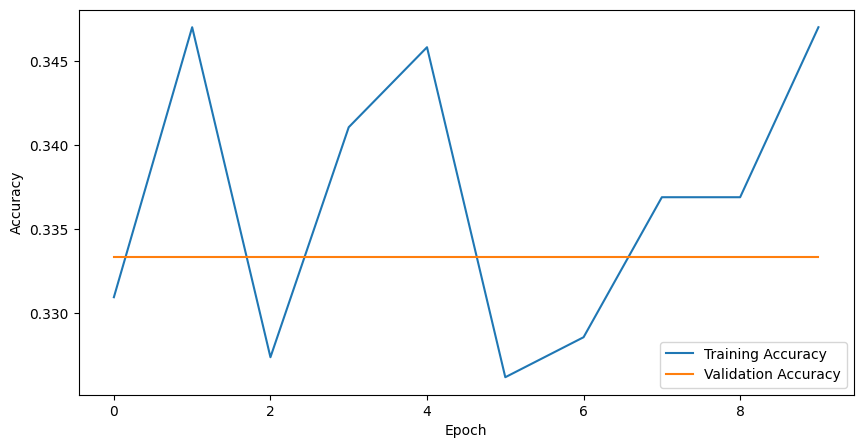

In [29]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

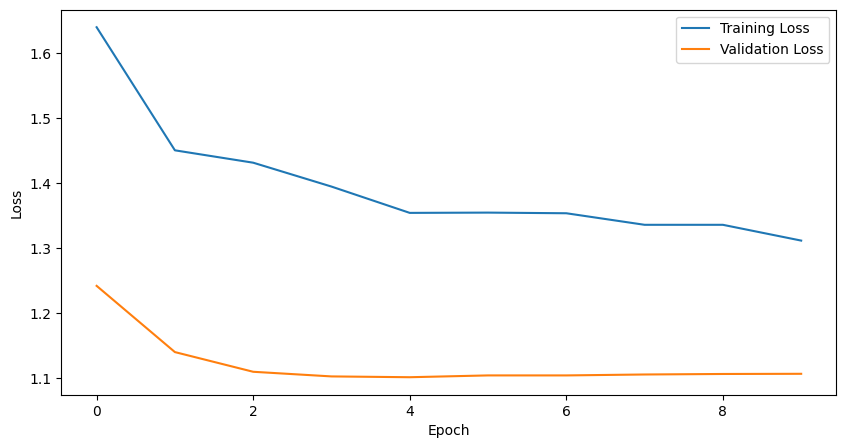

In [30]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [31]:
loss,accuracy=model.evaluate(validation_generator)

print("Validation Loss :",loss)
print("Validation Accuracy :",accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 152ms/step - accuracy: 0.3333 - loss: 1.1012
Validation Loss : 1.101181983947754
Validation Accuracy : 0.3333333432674408


In [ ]:
model.save("ResNet50_3class.h5")

In [ ]:
model.save("ResNet50_3class.keras")

In [36]:
from tensorflow.keras.preprocessing import image

img_path="/content/drive/MyDrive/Deep Learning/split_dataset/test/lung_n/lungn1018.jpeg"

img=image.load_img(img_path,target_size=(224,224))
img=image.img_to_array(img)
img=img/255.0
img=np.expand_dims(img,axis=0)

prediction=model.predict(img)

predicted_class=np.argmax(prediction)

class_labels=list(train_generator.class_indices.keys())

print("Predicted Class:",class_labels[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Predicted Class: lung_scc


In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
import seaborn as sns

pred=model.predict(validation_generator)

predicted=np.argmax(pred,axis=1)

true=validation_generator.classes

cm=confusion_matrix(true,predicted)

plt.figure(figsize=(6,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(
    true,
    predicted,
    target_names=list(train_generator.class_indices.keys())
))

29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 266ms/step


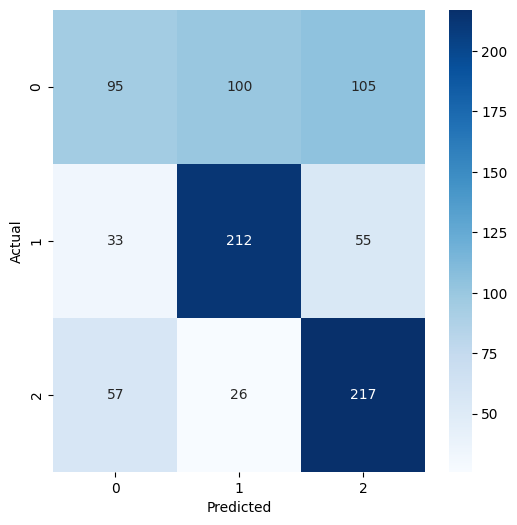

                                 precision    recall  f1-score   support

lung_aca-20260728T020146Z-1-001       0.51      0.32      0.39       300
  lung_n-20260728T020147Z-1-001       0.63      0.71      0.66       300
lung_scc-20260728T020437Z-1-001       0.58      0.72      0.64       300

                       accuracy                           0.58       900
                      macro avg       0.57      0.58      0.57       900
                   weighted avg       0.57      0.58      0.57       900



In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
import seaborn as sns

pred=model.predict(validation_generator)

predicted=np.argmax(pred,axis=1)

true=validation_generator.classes

cm=confusion_matrix(true,predicted)

plt.figure(figsize=(6,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(
    true,
    predicted,
    target_names=list(train_generator.class_indices.keys())
))

In [ ]:
import os

dataset_path = "/content/drive/MyDrive/Deep Learning/split_dataset/val"

for folder in os.listdir(dataset_path):
    count=len(os.listdir(os.path.join(dataset_path,folder)))
    print(folder, count)

lung_n-20260728T020147Z-1-001 300
lung_aca-20260728T020146Z-1-001 300
lung_scc-20260728T020437Z-1-001 300
